# Docling's native document format — what it contains beyond Markdown and JSON

Everything this project has concluded about Docling so far was drawn from its
**exports**: the Markdown the extractor consumes, and the document JSON
(`export_to_dict`). Both are the last step of a longer pipeline, and most of what
Docling computes on the way is not in them. This notebook opens the native
`ConversionResult` and walks it level by level:

| level | object | what it holds | in Markdown? | in JSON? |
|---|---|---|---|---|
| 0 | `ConversionResult` | status, per-page **confidence report**, input hash, timings | no | no |
| 1 | `Page` | page size, **rendered image**, the layout model's **clusters with confidences** | no | no |
| 2 | `ParsedPage` | every text line / word / character with **font name, size, colour, OCR flag**; **hyperlinks**; shapes | no | no |
| 3 | `DoclingDocument` | typed items with **page + bbox + char span**, `orig` vs `text`, groups, furniture; extra exports (DocTags with location tokens) | partly | mostly |

For each native-only piece of information the question is the same: does it
carry something the pipeline's **annotated text blob** (pdfplumber's one string
with `**bold**` / `_italic_` / `++underline++` markers) relies on — and how well,
measured across all 10 samples? Section 6 collects the answers; section 7 says
what can and cannot be concluded from them.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import collections
import json
import logging
import re
import warnings

os.environ['TQDM_DISABLE'] = '1'
warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption

pd.set_option('display.max_colwidth', 64)
pd.set_option('display.width', 160)
SAMPLES = range(1, 11)

# The pipeline's options, plus two flags that keep the intermediate objects the
# default pipeline throws away once the document is assembled.
opts = PdfPipelineOptions()
opts.do_ocr = True
opts.do_table_structure = True
opts.generate_parsed_pages = True    # level 2: cells, hyperlinks, shapes
opts.generate_page_images = True     # level 1: rendered page image
converter = DocumentConverter(
    format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=opts)})

R = {n: converter.convert(f'data/input/pdfs/sample{n}.pdf') for n in SAMPLES}
print('converted', len(R), 'documents;', 'docling',
      __import__('importlib.metadata').metadata.version('docling'))


def blob(n):
    """pdfplumber's stage-1 text for sample n — the annotated blob."""
    return json.loads(Path(f'data/output/1_extracted/pdfplumber/sample{n}.json')
                      .read_text(encoding='utf-8'))[0]['text']


def blob_runs(n):
    t = blob(n)
    return {'bold':      re.findall(r'\*\* (.+?) \*\*', t),
            'italic':    re.findall(r'(?<![\w*+])_ (.+?) _(?![\w])', t),
            'underline': re.findall(r'\+\+ (.+?) \+\+', t)}


def gold_title(n):
    p = Path(f'data/input/ground_truth_old_version/sample{n}_dmp_old.json')
    return json.loads(p.read_text(encoding='utf-8'))['narrative']['template']['title']


converted 10 documents; docling 2.117.0


## 0. Level 0 — the `ConversionResult`

The object `DocumentConverter.convert()` returns. Besides the document it carries
a status, the input's hash and page count, and a **confidence report**: the layout
model's own estimate of how well it understood each page. Nothing downstream
keeps this.


In [2]:
res = R[2]
print('status      :', res.status.value)
print('input       :', res.input.file.name, '|', res.input.page_count, 'pages |',
      res.input.filesize, 'bytes | hash', res.document.origin.binary_hash)
print('confidence  :', type(res.confidence).__name__, '— fields:',
      [f for f in res.confidence.model_dump() if f != 'pages'])
print()
rows = []
for n, r in R.items():
    c = r.confidence
    rows.append({'sample': n, 'pages': r.input.page_count,
                 'layout_score': round(c.layout_score, 3), 'parse_score': c.parse_score,
                 'mean_grade': c.mean_grade.value, 'low_grade': c.low_grade.value,
                 'lowest page': round(min(p.layout_score for p in c.pages.values()), 3)})
display(pd.DataFrame(rows).set_index('sample'))


status      : success
input       : sample2.pdf | 5 pages | 111819 bytes | hash 3086937458340468896
confidence  : ConfidenceReport — fields: ['parse_score', 'layout_score', 'table_score', 'ocr_score', 'mean_grade', 'low_grade', 'mean_score', 'low_score']



,pages,layout_score,parse_score,mean_grade,low_grade,lowest page
sample,,,,,,
1,2,0.884,1.0,excellent,good,0.853
2,5,0.820,1.0,excellent,good,0.770
3,3,0.850,1.0,excellent,good,0.828
4,2,0.946,1.0,excellent,excellent,0.937
5,2,0.931,1.0,excellent,excellent,0.917
6,1,0.949,1.0,excellent,excellent,0.949
7,1,0.948,1.0,excellent,excellent,0.948
8,2,0.935,1.0,excellent,excellent,0.930
9,3,0.927,1.0,excellent,excellent,0.915


`parse_score` is 1.0 everywhere — every page had a clean text layer, so OCR never
ran and `ocr_score` is undefined. `layout_score` is the layout model's confidence in
its own region labels, 0.77–0.92 by page. This is the only place in Docling that
says *how sure it is*; the exports present every heading as equally certain.


## 1. Level 1 — pages and the layout model's predictions

Each `Page` has its size, a rendered image, and `predictions.layout.clusters`:
the regions the layout model drew, each with a label, a **confidence**, a bounding
box and the text cells it contains. The JSON keeps the label and the box; the
confidence and the cell membership are dropped.


In [3]:
page = R[2].pages[0]
print('page size:', page.size.width, 'x', page.size.height, 'pt |',
      'image:', page.image.size if page.image else None, '|',
      'predictions:', [k for k, v in page.predictions.model_dump().items() if v])
rows = [{'id': c.id, 'label': str(c.label), 'confidence': round(c.confidence, 3),
         'cells': len(c.cells),
         'bbox (l, t, r, b)': tuple(round(v) for v in (c.bbox.l, c.bbox.t, c.bbox.r, c.bbox.b)),
         'text': c.cells[0].text[:50] if c.cells else ''}
        for c in sorted(page.predictions.layout.clusters, key=lambda c: c.bbox.t)]
display(pd.DataFrame(rows).set_index('id'))


page size: 612.0 x 792.0 pt | image: (612, 792) | predictions: ['layout', 'tablestructure']


,label,confidence,cells,"bbox (l, t, r, b)",text
id,,,,,
13,section_header,0.524,1,"(78, 68, 300, 79)",Center for Bio-Inspired Energy Science
10,list_item,0.794,1,"(78, 92, 263, 103)",1. Data sharing and preservation
0,text,0.906,7,"(78, 130, 531, 219)",Data management plans should describe whether and
3,text,0.874,6,"(78, 235, 530, 296)",Roles & Responsibilities.
8,text,0.835,4,"(78, 336, 521, 371)",Data Types and Sources.
2,text,0.889,7,"(78, 387, 533, 474)",The proposed research in this proposal includes bo
6,text,0.840,2,"(78, 490, 532, 512)","In most cases, the raw data will be converted to s"
1,text,0.899,7,"(78, 552, 533, 626)",Content and Format.
11,text,0.768,1,"(78, 642, 510, 650)",Data are output from the various instruments in la


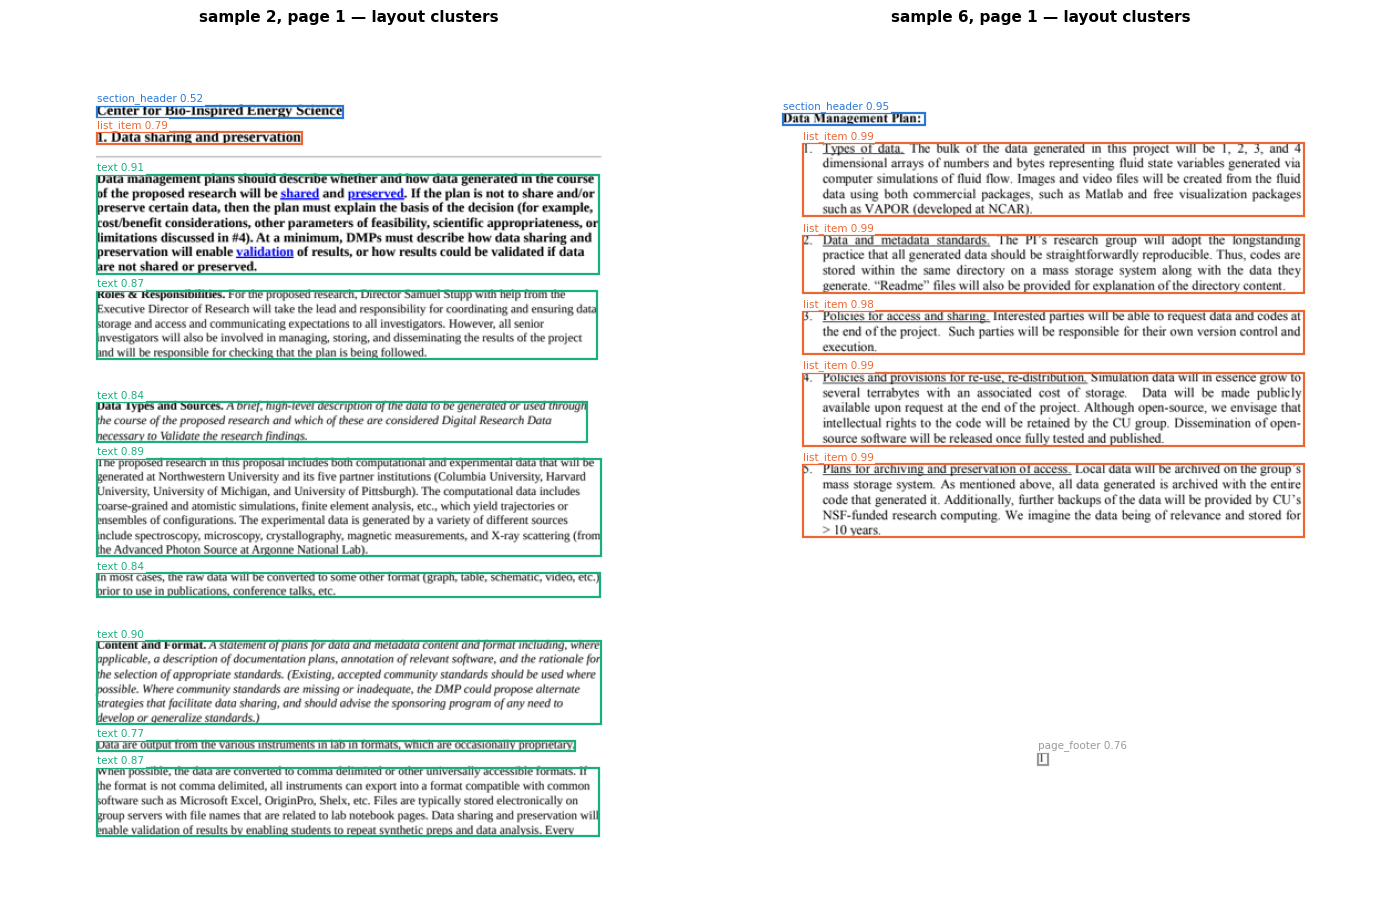

In [4]:
COLOURS = {'section_header': '#2a78d6', 'text': '#1baf7a', 'list_item': '#eb6834',
           'page_header': '#999', 'page_footer': '#999', 'table': '#8e44ad'}

# page.image is the 72-dpi render Docling keeps; a higher-resolution one would
# need the PDF backend, which is unloaded once conversion finishes.
S = 1.0
fig, axes = plt.subplots(1, 2, figsize=(14, 9.5))
for ax, n in zip(axes, (2, 6)):
    pg = R[n].pages[0]
    ax.imshow(pg.image)
    for c in pg.predictions.layout.clusters:
        col = COLOURS.get(str(c.label), '#333')
        l, t, r, b = (v * S for v in (c.bbox.l, c.bbox.t, c.bbox.r, c.bbox.b))
        ax.add_patch(plt.Rectangle((l, t), r - l, b - t, fill=False, lw=1.6, ec=col))
        ax.text(l, t - 1.5, f'{c.label} {c.confidence:.2f}', fontsize=7.5, color=col,
                va='bottom', bbox=dict(facecolor='white', alpha=0.9, lw=0, pad=1.2))
    ax.set_title(f'sample {n}, page 1 — layout clusters', fontsize=11, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()


Sample 2 (left): the layout model draws one box per paragraph and labels the
title a `section_header` at 0.52 confidence — its least certain call on the page.
Sample 6 (right): the five underlined headings are inside five `list_item` boxes;
there is no region for the heading itself, so no export could ever contain one.
The boxes are the block boundaries the blob does not have.


## 2. Level 2 — the parsed page: cells, fonts, sizes, hyperlinks

Below the layout model is the PDF parser's own output, a `SegmentedPdfPage`:
every text line, every word and (optionally) every character as a `PdfTextCell`
with its **font name, rectangle (so its size), colour, text direction, OCR flag,
confidence and rendering mode**, plus the page's **hyperlinks**, shapes, widgets
and bitmaps. This is where the typography lives. The document is assembled from
these cells, and then they are discarded.


In [5]:
pp = R[2].pages[0].parsed_page
print('text lines:', len(pp.textline_cells), '| words:', len(pp.word_cells),
      '| chars:', len(pp.char_cells), '| hyperlinks:', len(pp.hyperlinks),
      '| shapes:', len(pp.shapes), '| widgets:', len(pp.widgets))
print('cell fields:', list(pp.textline_cells[0].model_dump().keys()))
rows = [{'text': c.text[:52], 'font': c.font_name.split('+')[-1],
         'size (pt)': round(c.rect.height, 1),
         'x': round(c.rect.to_bounding_box().l), 'y': round(c.rect.to_bounding_box().t),
         'colour': f"#{c.rgba.r:02x}{c.rgba.g:02x}{c.rgba.b:02x}", 'from_ocr': c.from_ocr}
        for c in pp.textline_cells[:16]]
display(pd.DataFrame(rows))


text lines: 44 | words: 479 | chars: 0 | hyperlinks: 3 | shapes: 0 | widgets: 0
cell fields: ['index', 'rgba', 'rect', 'text', 'orig', 'text_direction', 'confidence', 'from_ocr', 'rendering_mode', 'widget', 'font_key', 'font_name']


,text,font,size (pt),x,y,colour,from_ocr
0,Center for Bio-Inspired Energy Science,Tinos-Bold,10.7,78,68,#000000,False
1,1. Data sharing and preservation,Tinos-Bold,10.7,78,92,#000000,False
2,Data management plans should describe whether and ho,Tinos-Bold,9.8,78,130,#000000,False
3,of the proposed research will be shared and preserve,Tinos-Bold,9.8,78,144,#000000,False
4,"preserve certain data, then the plan must explain th",Tinos-Bold,9.8,78,156,#000000,False
5,"cost/benefit considerations, other parameters of fea",Tinos-Bold,9.8,78,170,#000000,False
6,"limitations discussed in #4). At a minimum, DMPs mus",Tinos-Bold,9.8,78,183,#000000,False
7,"preservation will enable validation of results, or h",Tinos-Bold,9.8,78,196,#000000,False
8,are not shared or preserved.,Tinos-Bold,9.8,78,210,#000000,False
9,Roles & Responsibilities.,Tinos-Bold,8.9,78,235,#000000,False


`Tinos-Bold`, `Tinos-Italic`, `Tinos-Regular` — the same font names pdfplumber
reads — and a size for every line. The first eight lines are the bold instruction
paragraph; line 9 is `Roles & Responsibilities.` alone in bold, its answer starting
on the next line in regular. The blob shows that as `** Roles & Responsibilities. ** For the…`;
the Markdown and JSON show it as one plain paragraph.

### 2a. Bold and italic, all ten samples

Lines whose font name says bold or italic, against the blob's marker runs. The
units differ — Docling counts *lines*, pdfplumber's markers wrap *runs* that can
span several lines — so the columns should agree in order of magnitude, not to
the unit. Where they disagree in kind, the reason is in the last column.


In [6]:
rows = []
for n, r in R.items():
    cells = [c for p in r.pages for c in p.parsed_page.textline_cells]
    sizes = collections.Counter(round(c.rect.height, 1) for c in cells)
    body = sizes.most_common(1)[0][0]
    larger = sum(1 for c in cells if c.rect.height > body + 0.5)
    fonts = sorted({c.font_name.split('+')[-1] for c in cells})
    br = blob_runs(n)
    rows.append({'sample': n, 'lines': len(cells), 'body size': body,
                 'bold-named lines': sum('Bold' in c.font_name for c in cells),
                 'blob bold runs': len(br['bold']),
                 'italic-named lines': sum('Italic' in c.font_name for c in cells),
                 'blob italic runs': len(br['italic']),
                 'lines larger than body': larger,
                 'fonts in document': ', '.join(fonts)[:70]})
display(pd.DataFrame(rows).set_index('sample'))


,lines,body size,bold-named lines,blob bold runs,italic-named lines,blob italic runs,lines larger than body,fonts in document
sample,,,,,,,,
1,122,10.4,29,16,7,3,1,"Arial-BoldMT, Arial-ItalicMT, ArialMT, Calibri, Calibri-Bold"
2,185,8.9,42,42,41,41,35,"Tinos-Bold, Tinos-Italic, Tinos-Regular"
3,70,11.4,0,26,0,0,26,TimesLTPro-Roman
4,93,9.8,3,1,0,0,2,"Arial-BoldMT, TimesNewRomanPSMT"
5,122,9.1,18,16,5,5,7,"ArialMT, SymbolMT, TimesNewRomanPS-BoldMT, TimesNewRomanPS-I..."
6,62,10.7,2,5,0,0,5,"ArialMT, TimesNewRoman, TimesNewRomanPS-BoldMT, TimesNewRoma..."
7,20,9.8,1,1,0,0,0,"Arial-BoldMT, ArialMT"
8,94,8.7,10,2,14,12,1,"Arial-BoldMT, Times-Bold, Times-BoldItalic, Times-Italic, Ti..."
9,86,11.4,0,7,0,0,7,TimesLTPro-Roman


Where a document encodes emphasis in the font name, the cells carry it exactly:
sample 2 is 42/42 bold and 41/41 italic; sample 5 matches within the line-vs-run
difference. The three kinds of disagreement each have a typographic reason, and
in every case the cells hold the information:

- **Samples 8 and 10** — 10 and 7 bold-named lines against 2 and 1 blob runs. Their
  headings are set in `Times-BoldItalic` / `TimesNewRomanPS-BoldItalicMT`. The
  font name says both; pdfplumber's rule files a bold-italic font under *italic*
  only, so the blob marks them `_…_`. Same font names, different convention.
- **Samples 3 and 9** — no bold-named font at all, yet 26 and 7 blob bold runs.
  Their emphasis is a *larger size* in the regular face, which pdfplumber's rule
  also counts as bold; the cells carry the size (`lines larger than body`: 26, 7).
- **Sample 1** — 29 bold lines against 16 runs is only the unit: a bold heading
  that wraps is two lines and one run.

So the native cells hold everything pdfplumber's bold/italic rules read — font
name and size per line, per word. What is missing is only the rule that turns
them into a marker.

### 2b. Underline: hyperlinks, and the shapes that are not there

A PDF underline is either a hyperlink annotation or a drawn line. Docling's parsed
page reports hyperlinks with a rectangle each; it reports no drawn shapes on any
of these documents.


In [7]:
rows = []
for n, r in R.items():
    links = [h for p in r.pages for h in p.parsed_page.hyperlinks]
    shapes = sum(len(p.parsed_page.shapes) for p in r.pages)
    br = blob_runs(n)
    rows.append({'sample': n, 'hyperlinks': len(links), 'drawn shapes': shapes,
                 'blob underline runs': len(br['underline']),
                 'blob underlines': '; '.join(u[:22] for u in br['underline'][:4])})
display(pd.DataFrame(rows).set_index('sample'))


def link_text(r, page_idx, h):
    """Words of the page whose centre falls inside the hyperlink's rectangle.
    Link rectangles and word boxes may use different origins, so both are
    brought to top-left before comparing."""
    pg = r.pages[page_idx]
    H = pg.size.height
    hb = h.rect.to_bounding_box().to_top_left_origin(page_height=H)
    words = []
    for w in pg.parsed_page.word_cells:
        b = w.rect.to_bounding_box().to_top_left_origin(page_height=H)
        cx, cy = (b.l + b.r) / 2, (b.t + b.b) / 2
        if hb.l - 1 <= cx <= hb.r + 1 and hb.t - 1 <= cy <= hb.b + 1:
            words.append(w.text)
    return ' '.join(words)

for n in (1, 2):
    found = [link_text(R[n], i, h) for i, p in enumerate(R[n].pages) for h in p.parsed_page.hyperlinks]
    print(f'sample {n} — text under each hyperlink rectangle ({len(found)}):')
    for t in found:
        print('   ', repr(t))
    print('    blob underline runs:', [u for u in blob_runs(n)['underline']])
    print()


,hyperlinks,drawn shapes,blob underline runs,blob underlines
sample,,,,
1,1,0,2,Please see Element 5 f; about other studies.
2,13,0,11,shared; preserved.; validation; Principles
3,0,0,0,
4,0,0,0,
5,1,0,0,
6,0,0,5,Types of data.; Data and metadata stan; Policies for access ...
7,0,0,0,
8,0,0,0,
9,2,0,0,


sample 1 — text under each hyperlink rectangle (1):
    'on'
    blob underline runs: ['Please see Element 5 for data access information', 'about other studies.']

sample 2 — text under each hyperlink rectangle (13):
    'shared'
    'preserved.'
    'validation'
    'https://arch.library.northwestern.edu/'
    'Principles'
    'description of data management resources'
    'additional guidance from the sponsporing program.'
    'description of data management resources'
    'additional guidance'
    'from the sponsoring program.'
    '(https://arch.library.northwestern.edu/).'
    'Personally'
    'Identifiable Information'
    blob underline runs: ['shared', 'preserved.', 'validation', 'Principles', 'description of data management resources', 'additional guidance from the sponsporing program.', 'description of data management resources', 'additional guidance', 'from the sponsoring program.', 'Personally', 'Identifiable Information']



Every underline in sample 2 is a **hyperlink** — `shared`, `preserved`,
`validation`, `description of data management resources`, all eleven — and the
parsed page has a rectangle for each, with the words under it recoverable from
the word cells; the two extra links are raw URLs, which pdfplumber skips on
purpose. What the parsed page does not have is **drawn lines**: sample 1's
underlined sentence (its one link covers a single word), sample 6's five
underlined headings and sample 10's underlined title are graphics, `shapes` is
empty on every page, and so they are invisible at every level of Docling, not
only in the exports. So: link-underlines recoverable — 11 of the blob's 19
underline runs, all on sample 2 — drawn underlines not.

### 2c. Font size as a title signal

Cells carry a size; the exports do not. Is the largest line on page 1 the title?


In [8]:
rows = []
for n, r in R.items():
    cells = [c for c in r.pages[0].parsed_page.textline_cells if c.text.strip()]
    big = max(cells, key=lambda c: c.rect.height)
    top = min(cells, key=lambda c: c.rect.to_bounding_box().t)
    g = gold_title(n)
    rows.append({'sample': n, 'gold title': g[:34],
                 'largest line on p1': big.text.strip()[:34], 'largest = title': g[:20] in big.text,
                 'topmost line on p1': top.text.strip()[:34], 'topmost = title': g[:20] in top.text})
df = pd.DataFrame(rows).set_index('sample')
display(df)
print('largest-font rule finds the title on', int(df['largest = title'].sum()), 'of 10;',
      'topmost-line rule on', int(df['topmost = title'].sum()), 'of 10')


,gold title,largest line on p1,largest = title,topmost line on p1,topmost = title
sample,,,,,
1,DATA MANAGEMENT AND SHARING PLAN,A.,False,DATA MANAGEMENT AND SHARING PLAN,True
2,Center for Bio-Inspired Energy Sci,Center for Bio-Inspired Energy Sci,True,Center for Bio-Inspired Energy Sci,True
3,CPS 2015,CPS 2015,True,CPS 2015,True
4,DATA MANAGEMENT PLAN,DATA MANAGEMENT PLAN,True,DATA MANAGEMENT PLAN,True
5,DATA MANAGEMENT PLAN,DATA MANAGEMENT PLAN,True,DATA MANAGEMENT PLAN,True
6,Data Management Plan,Data Management Plan:,True,Data Management Plan:,True
7,Resource/Data Sharing Plan,The study investigators are commit,False,Resource/Data Sharing Plan,True
8,"Univ. of California, Riverside Dat","Univ. of California, Riverside Dat",True,"Univ. of California, Riverside Dat",True
9,CAREER: HIGH-RESOLUTION NMR FOR PA,CAREER: HIGH-RESOLUTION NMR FOR PA,True,CAREER: HIGH-RESOLUTION NMR FOR PA,True


largest-font rule finds the title on 7 of 10; topmost-line rule on 10 of 10


The largest font on page 1 is the title on 7 of 10; the **topmost line on page 1**
is the title on **10 of 10**. That second rule uses nothing but cell positions —
and it beats both reading order (which put sample 1's title at the end of the
page) and the topmost `section_header` (9 of 10), because it does not depend on
the layout model having labelled the title at all.


## 3. Word cells — recovering the inline label the exports fuse

The pattern that costs the most in this corpus is `Label. Answer text…` on one
line: a bold phrase that the annotation calls `question.text`, followed by its
answer. Docling's document item contains both as one `text`; the blob shows
`** Label. ** Answer…`. But the item's bounding box selects its **word cells**, and
each word has a font — so the leading bold run can be read straight off.


In [9]:
def words_in(r, item):
    prov = item.prov[0]
    pg = r.pages[prov.page_no - 1]
    bb = prov.bbox.to_top_left_origin(page_height=pg.size.height)
    out = []
    for w in pg.parsed_page.word_cells:
        b = w.rect.to_bounding_box()
        if b.l >= bb.l - 1 and b.r <= bb.r + 1 and b.t >= bb.t - 1 and b.b <= bb.b + 1:
            out.append(w)
    return out


def leading_bold(r, item):
    words = words_in(r, item)
    lead = []
    for w in words:
        if 'Bold' in w.font_name:
            lead.append(w.text)
        else:
            break
    if lead and len(lead) < len(words):        # a prefix, not a wholly bold block
        return ' '.join(lead)
    return ''


rows = []
for it in R[2].document.texts:
    if str(it.label) == 'text' and it.prov:
        rows.append({'docling item (fused)': it.text[:58], 'leading bold words': leading_bold(R[2], it)})
display(pd.DataFrame(rows).head(12))


,docling item (fused),leading bold words
0,Data management plans should describe whether and how data,
1,"Roles & Responsibilities. For the proposed research, Direc",Roles & Responsibilities.
2,"Data Types and Sources. A brief, high-level description of",Data Types and Sources.
3,The proposed research in this proposal includes both compu,
4,"In most cases, the raw data will be converted to some othe",
5,Content and Format. A statement of plans for data and meta,Content and Format.
6,Data are output from the various instruments in lab in for,
7,"When possible, the data are converted to comma delimited o",
8,Public talks and outreach activities will generate audio a,
9,Data Sharing and Data Preservation. A description of the p,Data Sharing and Data Preservation.


In [10]:
rows = []
for n, r in R.items():
    found = [leading_bold(r, it) for it in r.document.texts
             if str(it.label) in ('text', 'list_item') and it.prov]
    found = [f for f in found if f]
    # the blob's equivalent: a line that opens with a bold run and continues in plain text
    blob_prefix = re.findall(r'^\*\* (.+?) \*\* \S', blob(n), re.M)
    rows.append({'sample': n, 'items with a leading bold run': len(found),
                 'blob lines opening with a bold run': len(blob_prefix),
                 'examples': '; '.join(f[:28] for f in found[:3])})
display(pd.DataFrame(rows).set_index('sample'))


,items with a leading bold run,blob lines opening with a bold run,examples
sample,,,
1,0,0,
2,8,7,Roles & Responsibilities.; Data Types and Sources.; Content ...
3,0,0,
4,0,0,
5,6,7,Input data:; Produced Data:; Raw data:
6,0,0,
7,0,0,
8,0,0,
9,0,0,


The label comes back exactly — `Roles & Responsibilities.`, `Data Types and
Sources.`, `Content and Format.` — and the corpus-wide count tracks the blob's
bold-prefix lines. This is information the JSON export has already destroyed; it
exists only at the word-cell level, and only when the pipeline is asked to keep
parsed pages.


## 4. Level 3 — the `DoclingDocument` items, every field

The document itself is richer than the JSON dump suggests, but only slightly.
One item in full, then the fields that the Markdown never shows.


In [11]:
doc = R[2].document
it = doc.texts[3]
print('item fields  :', [f for f in it.model_dump()])
print('self_ref     :', it.self_ref, '| parent:', it.parent.cref, '| layer:', it.content_layer.value)
print('label        :', it.label.value, '| formatting:', it.formatting, '| hyperlink:', it.hyperlink)
print('prov         :', {'page': it.prov[0].page_no, 'bbox': {k: round(v) for k, v in it.prov[0].bbox.model_dump().items() if k != 'coord_origin'},
                        'charspan': it.prov[0].charspan})
print('text         :', it.text[:80])
print()
diff = [(t.orig[:40], t.text[:40]) for r in R.values() for t in r.document.texts if t.orig != t.text]
print(f'items where orig != text (parser text vs cleaned): {len(diff)} across the corpus')
for o, t in diff[:3]:
    print('   ', repr(o), '->', repr(t))
print()
print('groups in sample 2:', [(g.name, g.label.value, len(g.children)) for g in doc.groups])
print('furniture items in corpus:', sum(1 for r in R.values() for t in r.document.texts
                                        if t.content_layer.value == 'furniture'))
print('items carrying a hyperlink attribute:', sum(1 for r in R.values() for t in r.document.texts if t.hyperlink))


item fields  :

 ['self_ref', 'parent', 'children', 'content_layer', 'meta', 'label', 'prov', 'orig', 'text', 'formatting', 'hyperlink']
self_ref     : #/texts/3 | parent: #/body | layer: body
label        : text | formatting: None | hyperlink: None
prov         : {'page': 1, 'bbox': {'l': 78, 't': 557, 'r': 530, 'b': 496}, 'charspan': (0, 462)}
text         : Roles & Responsibilities. For the proposed research, Director Samuel Stupp with 

items where orig != text (parser text vs cleaned): 10 across the corpus
    '1. Data sharing and preservation' -> 'Data sharing and preservation'
    '3. Data management resources' -> 'Data management resources'
    '· Section 2.1 characterizes the aquifer ' -> 'Section 2.1 characterizes the aquifer fo'

groups in sample 2: [('list', 'list', 1), ('list', 'list', 7), ('list', 'list', 1)]
furniture items in corpus: 2
items carrying a hyperlink attribute: 0


Two things worth knowing. `charspan` and `bbox` give every item a place on a page —
the blob has no idea where any of its text came from. And the `hyperlink` and
`formatting` attributes exist on every item but are never filled for PDFs: the
links found on the parsed page in section 2b do not reach the document.

### Other exports — DocTags keeps position

Besides Markdown and JSON, the document exports to HTML, plain text and
**DocTags**, a token format that keeps each item's label and location.


In [12]:
print(doc.export_to_doctags()[:600])


<doctag><section_header_level_1><loc_64><loc_43><loc_245><loc_50>Center for Bio-Inspired Energy Science</section_header_level_1>
<ordered_list><list_item><loc_64><loc_58><loc_215><loc_65>Data sharing and preservation</list_item>
</ordered_list>
<text><loc_64><loc_82><loc_434><loc_139>Data management plans should describe whether and how data generated in the course of the proposed research will be shared and preserved. If the plan is not to share and/or preserve certain data, then the plan must explain the basis of the decision (for example, cost/benefit considerations, other parameters of fea


## 5. Level by level: what each representation carries

| information | pdfplumber blob | Docling Markdown | Docling JSON | Docling native | native level |
|---|---|---|---|---|---|
| block boundaries | no | yes | yes | yes | 1, 3 |
| heading vs body | bold marker | `##` | `section_header` | + confidence | 1 |
| layout confidence | — | no | no | **yes** | 0, 1 |
| page / position of every block | no | no | bbox | bbox + cluster + cells | 1, 3 |
| page image | no | no | no | **yes** | 1 |
| bold (font name) | `**` | no | no | **yes**, per word | 2 |
| bold (larger size) | `**` | no | no | **yes**, size per line | 2 |
| italic | `_` | no | no | **yes**, per word | 2 |
| underline — hyperlink | `++` | no | no | **yes**, rectangles | 2 |
| underline — drawn line | `++` | no | no | **no** — shapes empty | — |
| colour | no | no | no | yes | 2 |
| OCR vs text-layer per cell | no | no | no | yes | 2 |
| inline `Label. Answer` split | marker shows it | fused | fused | **recoverable** from word cells | 2 + 3 |
| lists as groups | no | `-` | yes | yes | 3 |
| headers/footers separated | no | dropped | furniture | furniture | 3 |

Read down the *native* column: with parsed pages kept, Docling holds every
typographic signal the blob has except one (drawn underlines), and several the
blob lacks (boundaries, position, confidence, images, colour). Read the *Markdown*
and *JSON* columns: almost none of it survives export. The earlier finding that
"Docling does not report bold, italic or underline" was true of the exports; it is
not true of the native result.


## 6. What can be concluded, and what cannot yet

**Capabilities — established here.**

- The native result contains the font name and size of every word. On documents
  that encode emphasis in the font (2, 5, 8, 10) this reproduces the blob's bold
  and italic runs; on documents that encode it by size (3, 9) the size is there too.
  Nothing in the pipeline reads it, because the extractor works from Markdown.
- Hyperlink underlines are recoverable as rectangles; drawn underlines are not
  present at any level. Sample 6's headings stay out of reach of any Docling path.
- The inline `Label. Answer…` pattern — the single largest source of lost
  `question.text` in this corpus — is recoverable from word cells, exactly.
- The layout model's block boundaries, confidences and positions, and the page
  images, are native-only and have no counterpart in the blob at all.

**Effectiveness — not established, and this notebook does not claim it.**

Every score this project has for Docling (0.767 with gemma; 0.709 rules-only)
was measured on the *exports*, which section 5 shows discard the signals above.
Those numbers say how well Docling's Markdown works, not how well Docling's
native format could. Measuring that requires an extractor that builds the
annotated blob from level 2 — font names and sizes for `**`/`_`, hyperlink
rectangles for `++`, word cells to split inline labels, layout clusters for block
boundaries — and a run of the same models through the same evaluation. That is
the experiment this exploration justifies, and it has not been run.

What it would and would not change is also bounded by section 2: the ceiling is
roughly pdfplumber's signal set plus layout structure, minus drawn underlines.
So the plausible outcome is parity with pdfplumber on samples 1–5 and 7–10 and a
loss on sample 6 — not a new best, but a second, independently-derived source
of the same signals, with positions and confidences pdfplumber cannot give.
